In [9]:

from pathlib import Path
from time import time

import lightning as pl


from lit_ecology_classifier.data.datamodule import DataModule
from lit_ecology_classifier.models.model import LitClassifier

In [10]:
# path for the classifcation path
base_path = Path("..")
output_path = base_path / "output" / "classification"

output_path.mkdir(parents=True, exist_ok=True)
model_path = base_path / "models" / "benno" / "zoo3.ckpt"
data_path = base_path / "zoo3.tar"

In [11]:
model = LitClassifier.load_from_checkpoint(model_path)

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
model.hparams.batch_size = 32
model.hparams.TTA = False
model.hparams.outpath = str(output_path)
model.hparams.datapath = str(data_path)
model.hparams.use_wandb = False

In [13]:
print(model.hparams)

"TTA":              False
"balance_classes":  False
"batch_size":       32
"class_map":        {'aphanizomenon': 0, 'asplanchna': 1, 'asterionella': 2, 'bosmina': 3, 'ceratium': 4, 'chaoborus': 5, 'chlorophyte_colonial_reproduction': 6, 'chydorus': 7, 'collotheca': 8, 'conochilus': 9, 'copepod_skin': 10, 'cyclops': 11, 'daphnia': 12, 'daphnia_cucullata': 13, 'daphnia_skin': 14, 'diaphanosoma': 15, 'diatom_chain': 16, 'dinobryon': 17, 'eudiaptomus': 18, 'filament': 19, 'fish': 20, 'fragilaria': 21, 'hydra': 22, 'kellicottia': 23, 'keratella_cochlearis': 24, 'keratella_quadrata': 25, 'leptodora': 26, 'limnoraphis': 27, 'maybe_cyano': 28, 'nauplius': 29, 'paradileptus': 30, 'pennate_diatom': 31, 'polyarthra': 32, 'rotifer': 33, 'synchaeta': 34, 'trichocerca': 35, 'unknown': 36, 'uroglena': 37}
"datapath":         ../zoo3.tar
"dataset":          zoo3
"loss":             cross_entropy
"lr":               0.0001
"lr_factor":        0.01
"main_param_path":  ./params/
"max_epochs":       20
"n

In [14]:
data_module = DataModule(**model.hparams)
data_module.setup("test")
model.load_datamodule(data_module)

In [15]:
trainer = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path
    )
    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing: |          | 0/? [00:00<?, ?it/s]

test_roc_auc_binary: 0.9998326709893327
test_balanced_acc: 0.9322300786476191
test_false_positives: 0.03750000149011612
test_acc: 0.9376671466776384
test_f1: 0.9267536312098467
test_auc_macro: 0.9981447460201199
test_precision: 0.9229551177386108
test_recall: 0.9322300786476191


AttributeError: 'CSVLogger' object has no attribute 'log_image'

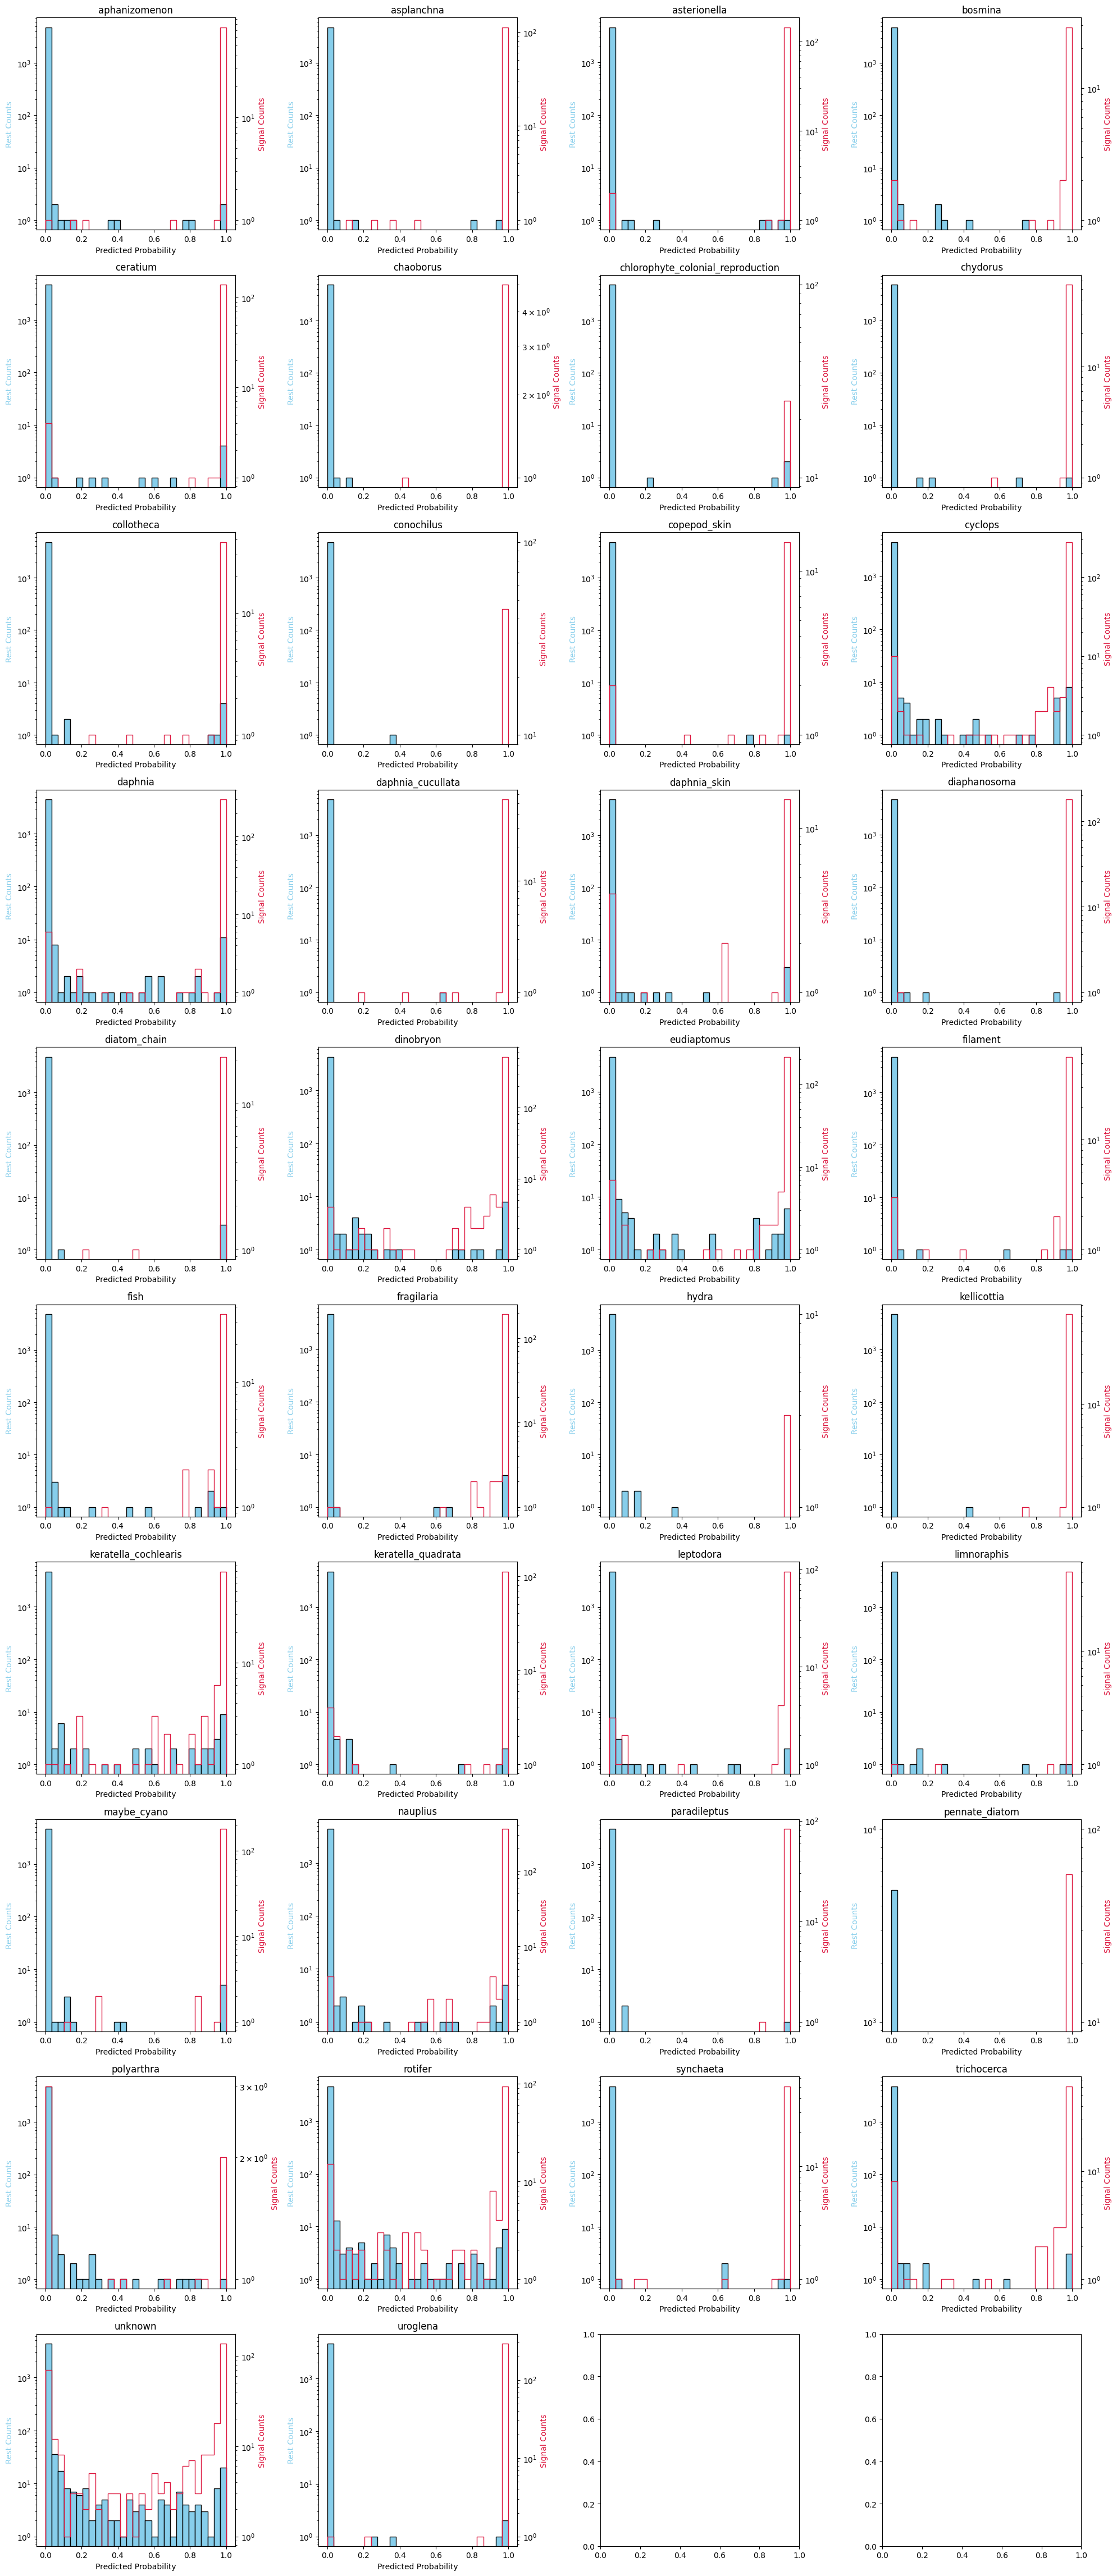

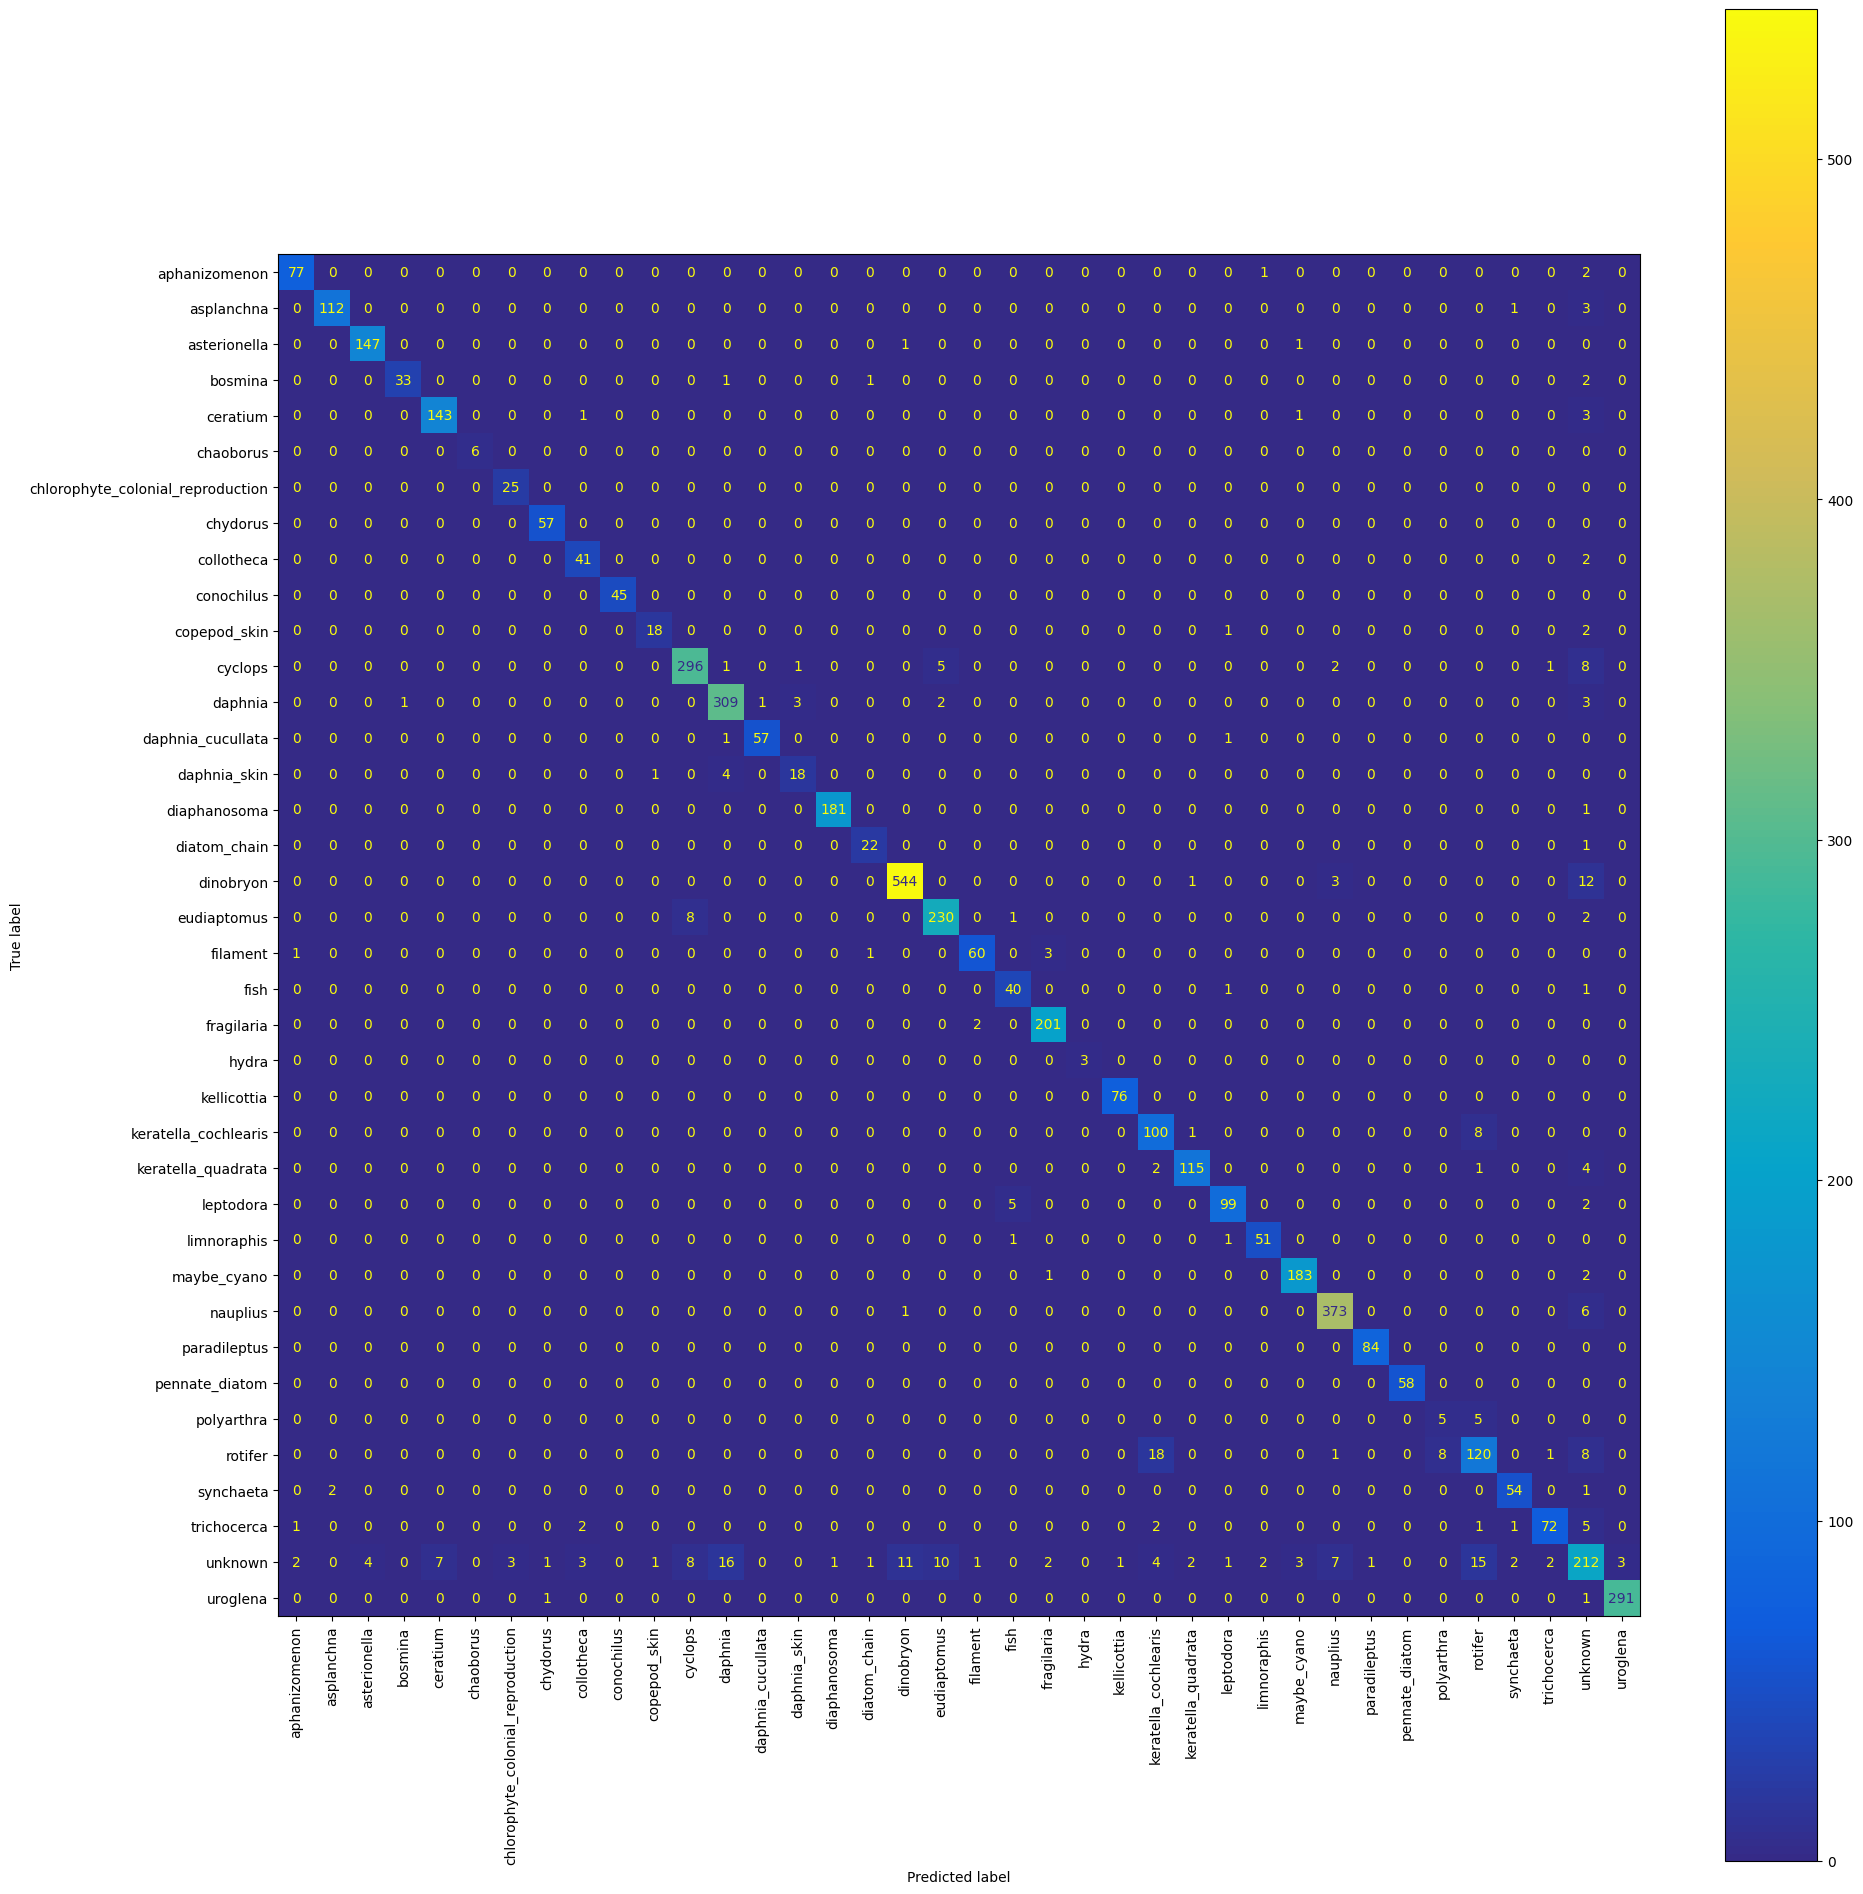

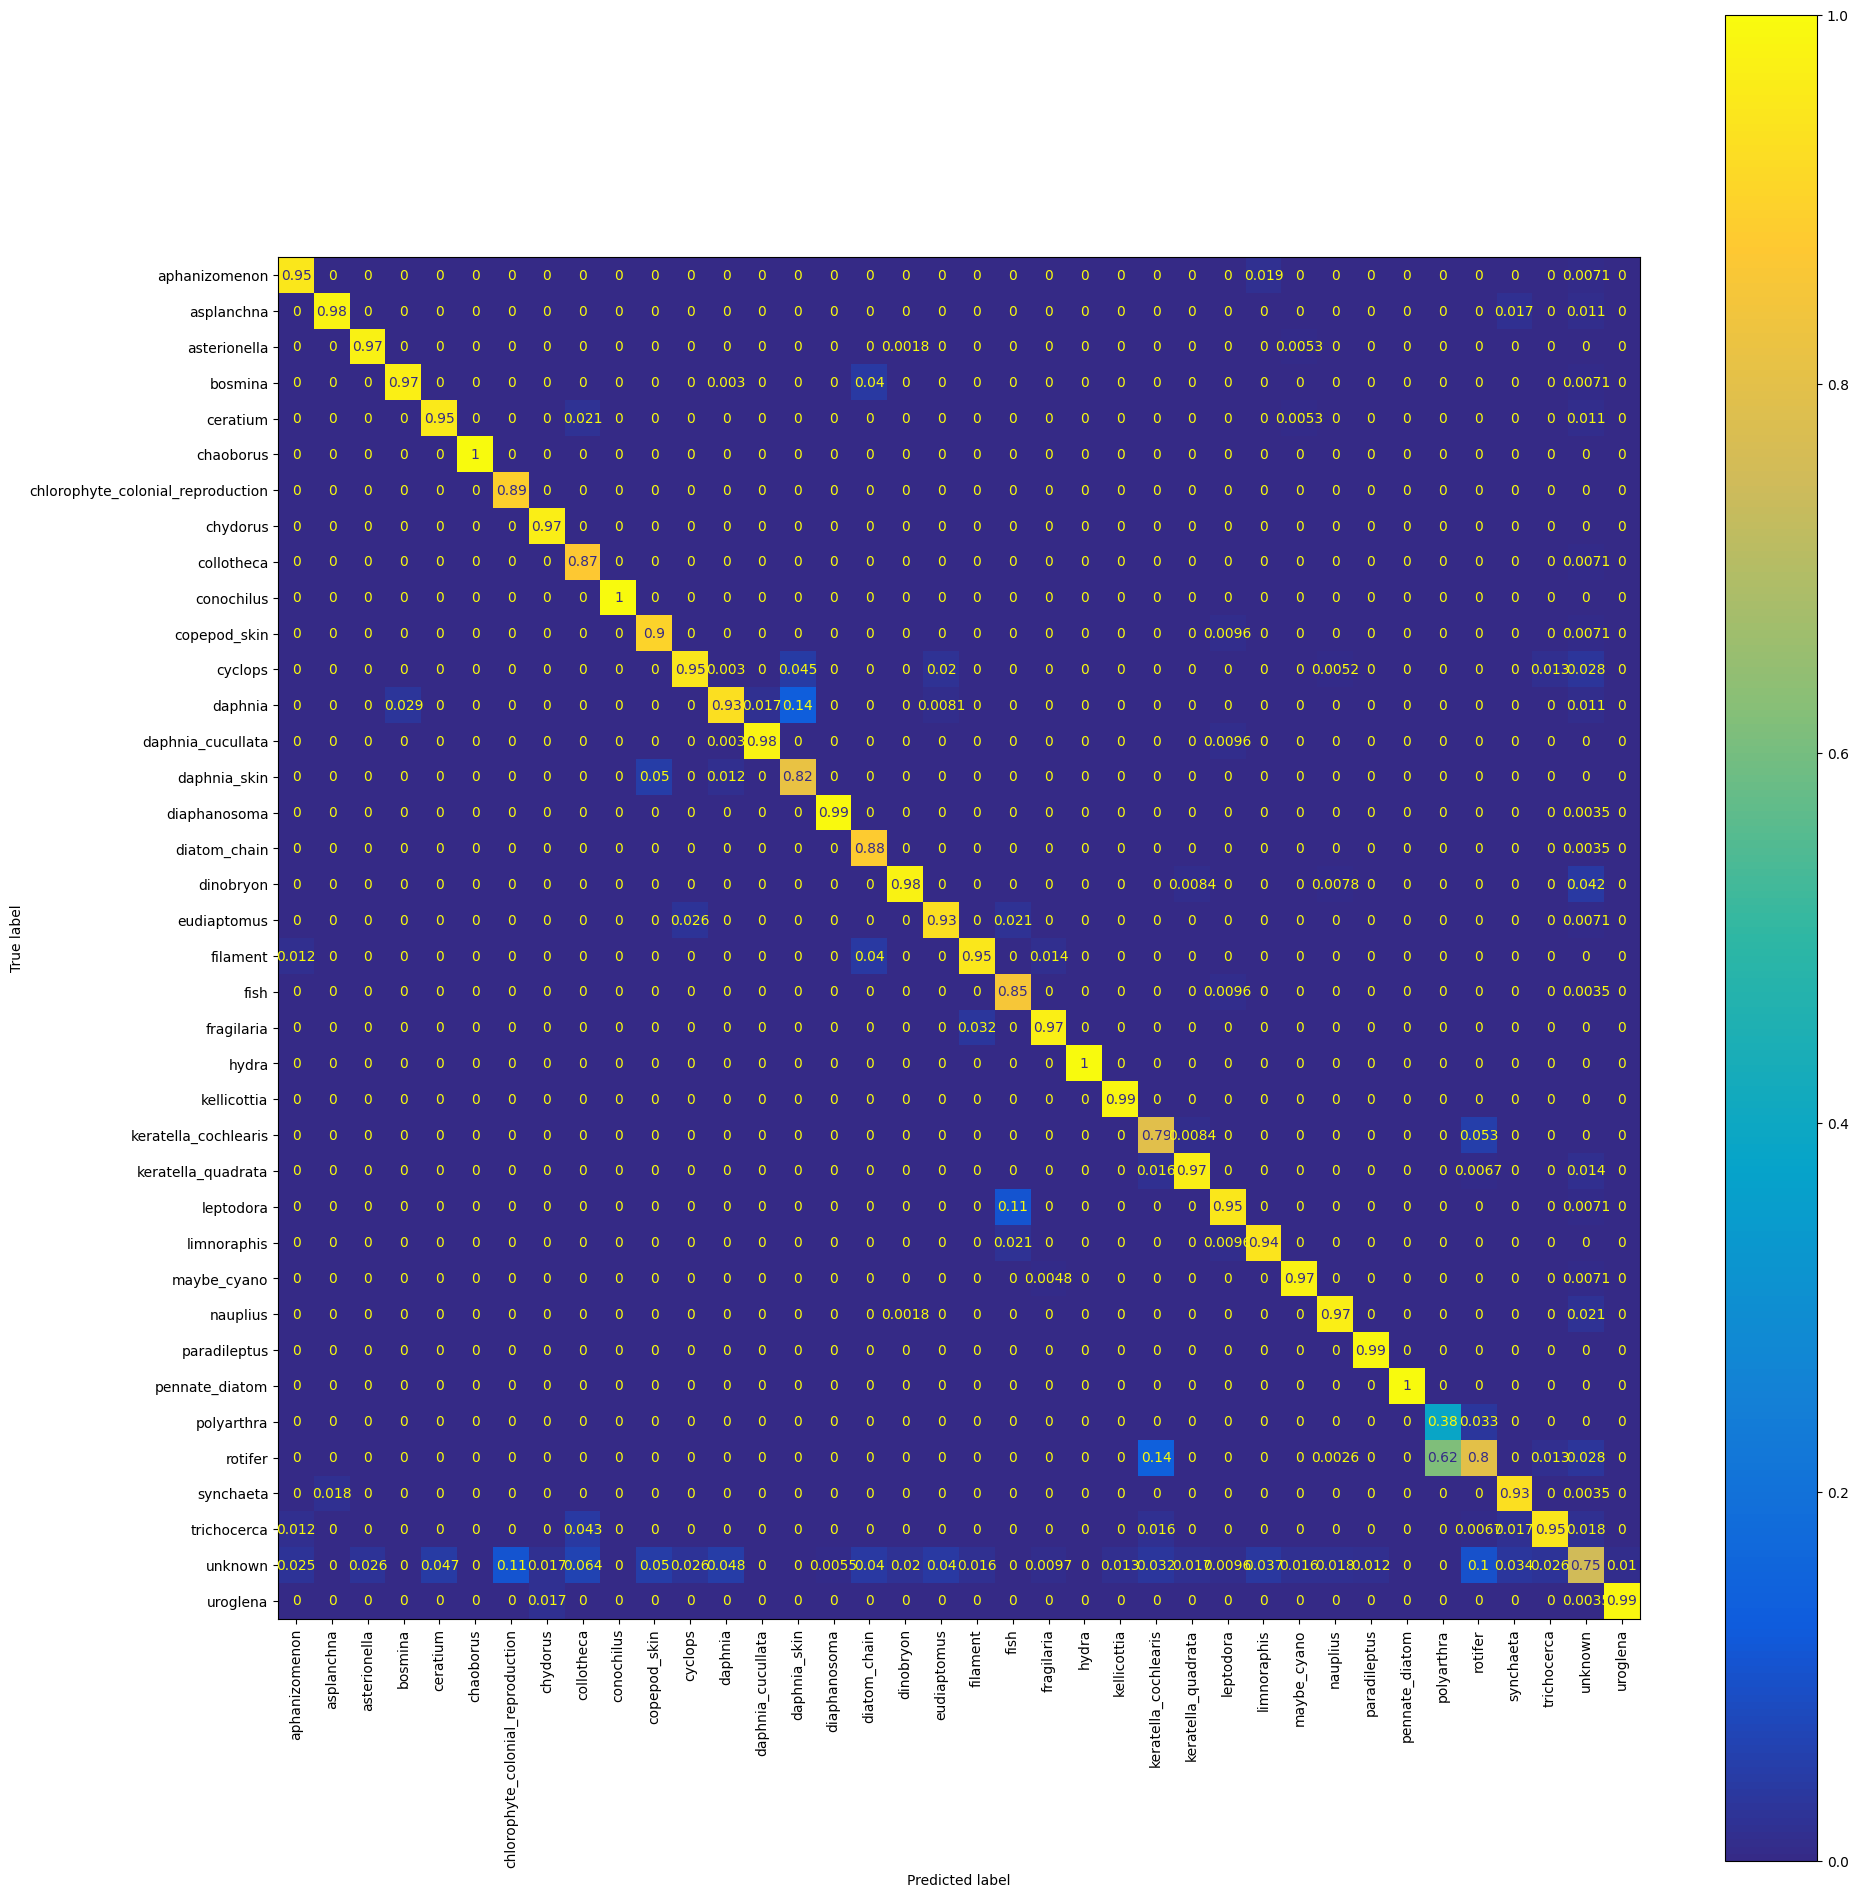

In [16]:
trainer.test(model, datamodule=data_module)